# LSTM Time-Series Forecasting Kualitas Udara

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

In [2]:
df = pd.read_csv('data_kualitas_udara.csv')
df.head()

,id,waktu,suhu,kelembaban,debu,gas_mq7,gas_mq135,kondisi
0,6,1970-01-01 07:00:06,31.1,68.3,281,1.0,1.0,Sedang
1,16,1970-01-01 07:00:16,32.0,66.4,286,1.0,1.0,Sedang
2,1783407319,2026-07-07 13:55:19,34.2,64.4,285,0.0,0.0,Tidak Sehat
3,1783407379,2026-07-07 13:56:19,34.2,64.0,279,0.0,0.0,Tidak Sehat
4,1783407439,2026-07-07 13:57:19,34.1,63.2,277,0.0,0.0,Tidak Sehat


In [3]:
df["waktu"] = pd.to_datetime(df["waktu"])
df = df.sort_values("waktu")
df.reset_index(drop=True, inplace=True)

df = df[df["waktu"].dt.year > 2000]
df.reset_index(drop=True, inplace=True)
df.head()

,id,waktu,suhu,kelembaban,debu,gas_mq7,gas_mq135,kondisi
0,1783407319,2026-07-07 13:55:19,34.2,64.4,285,0.0,0.0,Tidak Sehat
1,1783407379,2026-07-07 13:56:19,34.2,64.0,279,0.0,0.0,Tidak Sehat
2,1783407439,2026-07-07 13:57:19,34.1,63.2,277,0.0,0.0,Tidak Sehat
3,1783407499,2026-07-07 13:58:19,34.1,63.3,279,1.0,0.0,Tidak Sehat
4,1783407559,2026-07-07 13:59:19,34.0,63.3,278,1.0,0.0,Tidak Sehat


In [4]:
features=['suhu','kelembaban','debu','gas_mq7','gas_mq135']

scaler = MinMaxScaler()
scaled = scaler.fit_transform(df[features])

In [5]:
window = 60

X = []
y = []

for i in range(window, len(scaled)):
    X.append(scaled[i-window:i])
    y.append(scaled[i])

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(374, 60, 5)
(374, 5)


In [6]:
split = int(len(X)*0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [7]:
model = Sequential([Input(shape=(60,5)),LSTM(64,return_sequences=True),Dropout(0.2),LSTM(32),Dense(16,activation='relu'),Dense(5)])
model.compile(optimizer='adam',loss='mse',metrics=['mae'])
history = model.fit(X_train,y_train,epochs=20,batch_size=32,validation_data=(X_test,y_test))

Epoch 1/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - loss: 0.7667 - mae: 0.8169 - val_loss: 0.5714 - val_mae: 0.6940
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.5382 - mae: 0.6599 - val_loss: 0.3915 - val_mae: 0.5110
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.3765 - mae: 0.5005 - val_loss: 0.3219 - val_mae: 0.4722
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.2993 - mae: 0.4593 - val_loss: 0.2297 - val_mae: 0.4154
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.2167 - mae: 0.3965 - val_loss: 0.1608 - val_mae: 0.3554
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.1457 - mae: 0.3247 - val_loss: 0.0911 - val_mae: 0.2778
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0917 - mae: 0.2662 - val_loss: 0.0535 - val_mae: 0.2025
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0613 - mae: 0.2088 - val_loss: 0.0350 - val_mae: 0.1643
Epoch 9/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.046

HASIL EVALUASI REGRESI

Debu
MAE  : 0.5283
MSE  : 0.4294
RMSE : 0.6553
R²   : 0.4341

Suhu
MAE  : 4.0139
MSE  : 18.6768
RMSE : 4.3217
R²   : 0.2012

Kelembaban
MAE  : 4.7885
MSE  : 29.6095
RMSE : 5.4415
R²   : -0.6695

HASIL EVALUASI KLASIFIKASI

Gas_MQ7
Accuracy : 1.0000
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        75

    accuracy                           1.00        75
   macro avg       1.00      1.00      1.00        75
weighted avg       1.00      1.00      1.00        75


Gas_MQ135
Accuracy : 1.0000
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        75

    accuracy                           1.00        75
   macro avg       1.00      1.00      1.00        75
weighted avg       1.00      1.00      1.00        75



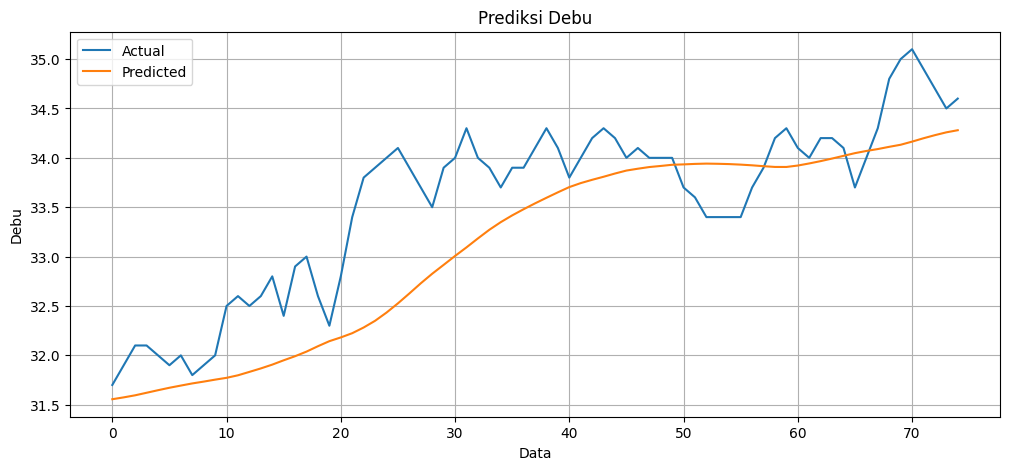

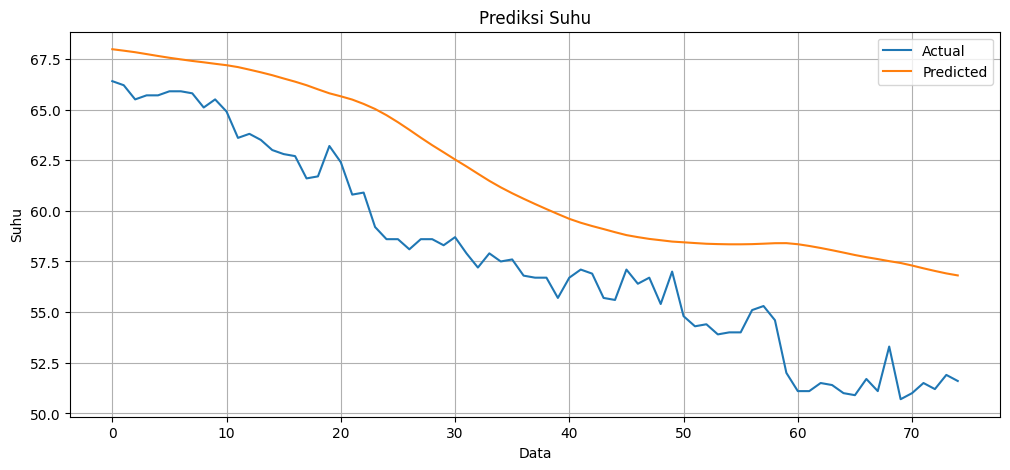

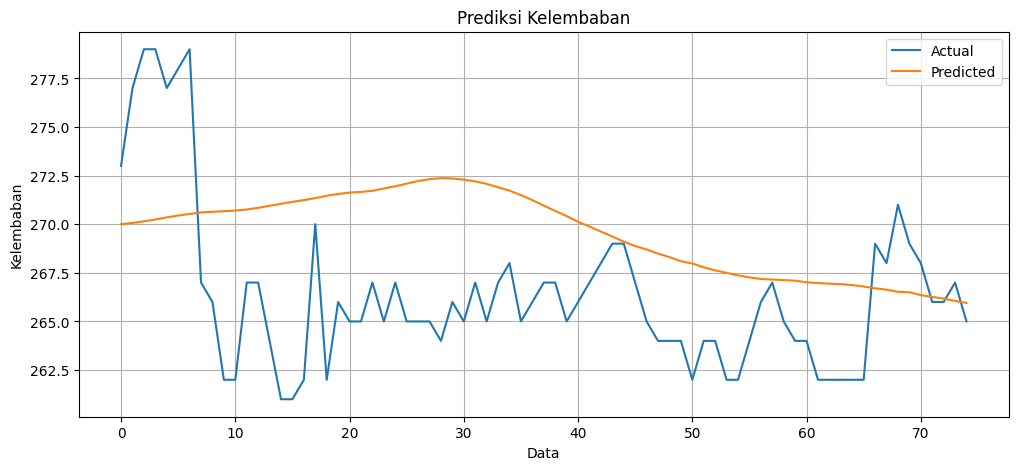

In [8]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    classification_report,
)

# ======================================
# Prediksi
# ======================================

pred = model.predict(X_test, verbose=0)

# Kembalikan ke nilai asli
pred_real = scaler.inverse_transform(pred)
true_real = scaler.inverse_transform(y_test)

# Nama fitur
feature_names = [
    "Debu",
    "Suhu",
    "Kelembaban",
    "Gas_MQ7",
    "Gas_MQ135"
]

# ======================================
# Evaluasi Regresi
# ======================================

print("="*70)
print("HASIL EVALUASI REGRESI")
print("="*70)

for i in range(3):

    mae = mean_absolute_error(true_real[:, i], pred_real[:, i])
    mse = mean_squared_error(true_real[:, i], pred_real[:, i])
    rmse = np.sqrt(mse)
    r2 = r2_score(true_real[:, i], pred_real[:, i])

    print(f"\n{feature_names[i]}")
    print(f"MAE  : {mae:.4f}")
    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}")

# ======================================
# Evaluasi MQ7 dan MQ135
# ======================================

print("\n" + "="*70)
print("HASIL EVALUASI KLASIFIKASI")
print("="*70)

for i in [3,4]:

    y_true = np.round(true_real[:, i]).astype(int)
    y_pred = np.round(pred_real[:, i]).astype(int)

    acc = accuracy_score(y_true, y_pred)

    print(f"\n{feature_names[i]}")
    print(f"Accuracy : {acc:.4f}")

    print(classification_report(
        y_true,
        y_pred,
        zero_division=0
    ))

# ======================================
# Grafik
# ======================================

for i in range(3):

    plt.figure(figsize=(12,5))

    plt.plot(true_real[:, i], label="Actual")
    plt.plot(pred_real[:, i], label="Predicted")

    plt.title(f"Prediksi {feature_names[i]}")
    plt.xlabel("Data")
    plt.ylabel(feature_names[i])

    plt.grid(True)
    plt.legend()

    plt.show()

In [9]:
features = [
    "suhu",
    "kelembaban",
    "debu",
    "gas_mq7",
    "gas_mq135"
]

feature_index = {
    name: i for i, name in enumerate(features)
}

# ======================================================
# FUNGSI MENENTUKAN KONDISI
# ======================================================

def air_status(debu, mq7, mq135):

    if debu > 400:
        return "Tidak Sehat"

    elif debu > 150:
        return "Sedang"

    elif mq7 == 0 and mq135 == 0:
        return "Sedang"

    else:
        return "Baik"

# ======================================================
# DATA SAAT INI
# ======================================================

current = df.iloc[-1]

current_time = pd.to_datetime(current["waktu"])

current_suhu = float(current["suhu"])
current_kelembaban = float(current["kelembaban"])
current_debu = float(current["debu"])

current_mq7 = int(current["gas_mq7"])
current_mq135 = int(current["gas_mq135"])

current_status = air_status(
    current_debu,
    current_mq7,
    current_mq135
)

# ======================================================
# PREDIKSI
# ======================================================

latest = X[-1].reshape(1, 60, len(features))

future_scaled = model.predict(latest, verbose=0)

# Supaya tidak keluar dari rentang MinMax
future_scaled = np.clip(future_scaled, 0, 1)

future = scaler.inverse_transform(future_scaled)

# ======================================================
# AMBIL HASIL SESUAI URUTAN FITUR
# ======================================================

future_suhu = future[0, feature_index["suhu"]]
future_kelembaban = future[0, feature_index["kelembaban"]]
future_debu = future[0, feature_index["debu"]]

future_mq7 = int(np.clip(round(future[0, feature_index["gas_mq7"]]), 0, 1))
future_mq135 = int(np.clip(round(future[0, feature_index["gas_mq135"]]), 0, 1))

future_status = air_status(
    future_debu,
    future_mq7,
    future_mq135
)

next_time = current_time + pd.Timedelta(hours=1)

# ======================================================
# HASIL
# ======================================================

print("=" * 60)
print("DATA SAAT INI")
print("=" * 60)

print(f"Waktu        : {current_time}")
print(f"Debu         : {current_debu:.2f}")
print(f"Suhu         : {current_suhu:.2f} °C")
print(f"Kelembaban   : {current_kelembaban:.2f} %")
print(f"MQ7          : {current_mq7}")
print(f"MQ135        : {current_mq135}")
print(f"Status       : {current_status}")

print()

print("=" * 60)
print("PREDIKSI 1 JAM BERIKUTNYA")
print("=" * 60)

print(f"Waktu        : {next_time}")
print(f"Debu         : {future_debu:.2f}")
print(f"Suhu         : {future_suhu:.2f} °C")
print(f"Kelembaban   : {future_kelembaban:.2f} %")
print(f"MQ7          : {future_mq7}")
print(f"MQ135        : {future_mq135}")
print(f"Status       : {future_status}")

DATA SAAT INI
Waktu        : 2026-07-09 11:10:31
Debu         : 265.00
Suhu         : 34.60 °C
Kelembaban   : 51.60 %
MQ7          : 1
MQ135        : 1
Status       : Sedang

PREDIKSI 1 JAM BERIKUTNYA
Waktu        : 2026-07-09 12:10:31
Debu         : 265.95
Suhu         : 34.28 °C
Kelembaban   : 56.81 %
MQ7          : 1
MQ135        : 1
Status       : Sedang
